# Phase of Play Transition Analyzer

This notebook demonstrates a comprehensive analysis of phase of play transitions in football matches, helping coaches and analysts understand tactical patterns and identify successful transition sequences.


## 1. Setup and Data Loading

We load phases of play data directly from the SkillCorner Open Data repository on GitHub.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import (
    load_matches_metadata,
    load_and_preprocess_match,
    load_multiple_matches
)
from src.transition_analyzer import (
    get_transition_counts,
    get_transition_success_rates,
    get_transition_network,
    get_common_sequences,
    get_team_comparison
)
from src.visualizer import (
    plot_transition_network,
    plot_transition_heatmap,
    plot_transition_success_rates,
    plot_sankey_diagram,
    plot_phase_distribution,
    plot_spatial_transition_heatmap
)

# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('default')
%matplotlib inline


In [26]:
# Load matches metadata
matches_df = load_matches_metadata()
print(f"Loaded {len(matches_df)} matches")
print("\nAvailable matches:")
matches_df[['id', 'home_team', 'away_team', 'date_time']].head(10)


Loaded 10 matches

Available matches:


,id,home_team,away_team,date_time
0,2017461,"{'id': 868, 'short_name': 'Melbourne V FC'}","{'id': 4177, 'short_name': 'Auckland FC'}",2025-05-17T09:35:00Z
1,2015213,"{'id': 1803, 'short_name': 'Western United'}","{'id': 4177, 'short_name': 'Auckland FC'}",2025-05-03T08:00:00Z
2,2013725,"{'id': 1803, 'short_name': 'Western United'}","{'id': 869, 'short_name': 'Sydney FC'}",2025-04-27T07:00:00Z
3,2011166,"{'id': 867, 'short_name': 'Wellington P FC'}","{'id': 868, 'short_name': 'Melbourne V FC'}",2025-04-12T05:00:00Z
4,2006229,"{'id': 2380, 'short_name': 'Melbourne City'}","{'id': 1804, 'short_name': 'Macarthur FC'}",2025-03-07T08:35:00Z
5,1996435,"{'id': 869, 'short_name': 'Sydney FC'}","{'id': 866, 'short_name': 'Adelaide United'}",2025-02-01T06:00:00Z
6,1953632,"{'id': 870, 'short_name': 'CC Mariners'}","{'id': 2380, 'short_name': 'Melbourne City'}",2024-12-31T08:00:00Z
7,1925299,"{'id': 1802, 'short_name': 'Brisbane FC'}","{'id': 871, 'short_name': 'Perth Glory'}",2024-12-21T06:00:00Z
8,1899585,"{'id': 4177, 'short_name': 'Auckland FC'}","{'id': 867, 'short_name': 'Wellington P FC'}",2024-12-07T04:00:00Z
9,1886347,"{'id': 4177, 'short_name': 'Auckland FC'}","{'id': 1805, 'short_name': 'Newcastle'}",2024-11-30T04:00:00Z


In [27]:
# Load phases of play data for multiple matches
match_ids = matches_df['id'].tolist()[:5]  # Analyze first 5 matches
phases_df = load_multiple_matches(match_ids)
print(f"Loaded phases for {phases_df['match_id'].nunique()} matches")
print(f"Total phases: {len(phases_df)}")
print(f"Total transitions: {phases_df['transition'].notna().sum()}")


Loaded phases for 5 matches
Total phases: 2296
Total transitions: 549


## 2. Transition Analysis

### 2.1 Most Common Transitions

Identifying the most frequently occurring phase transitions helps understand common tactical patterns.


In [28]:
# Get transition counts
transition_counts = get_transition_counts(phases_df)
print("Top 10 Most Common Transitions:")
transition_counts.head(10)


Top 10 Most Common Transitions:


,transition,count
10,create -> build_up,123
14,create -> finish,95
21,finish -> create,87
2,build_up -> create,77
12,create -> create,24
16,direct -> create,22
3,build_up -> direct,20
13,create -> direct,14
23,finish -> set_play,13
6,chaotic -> create,13


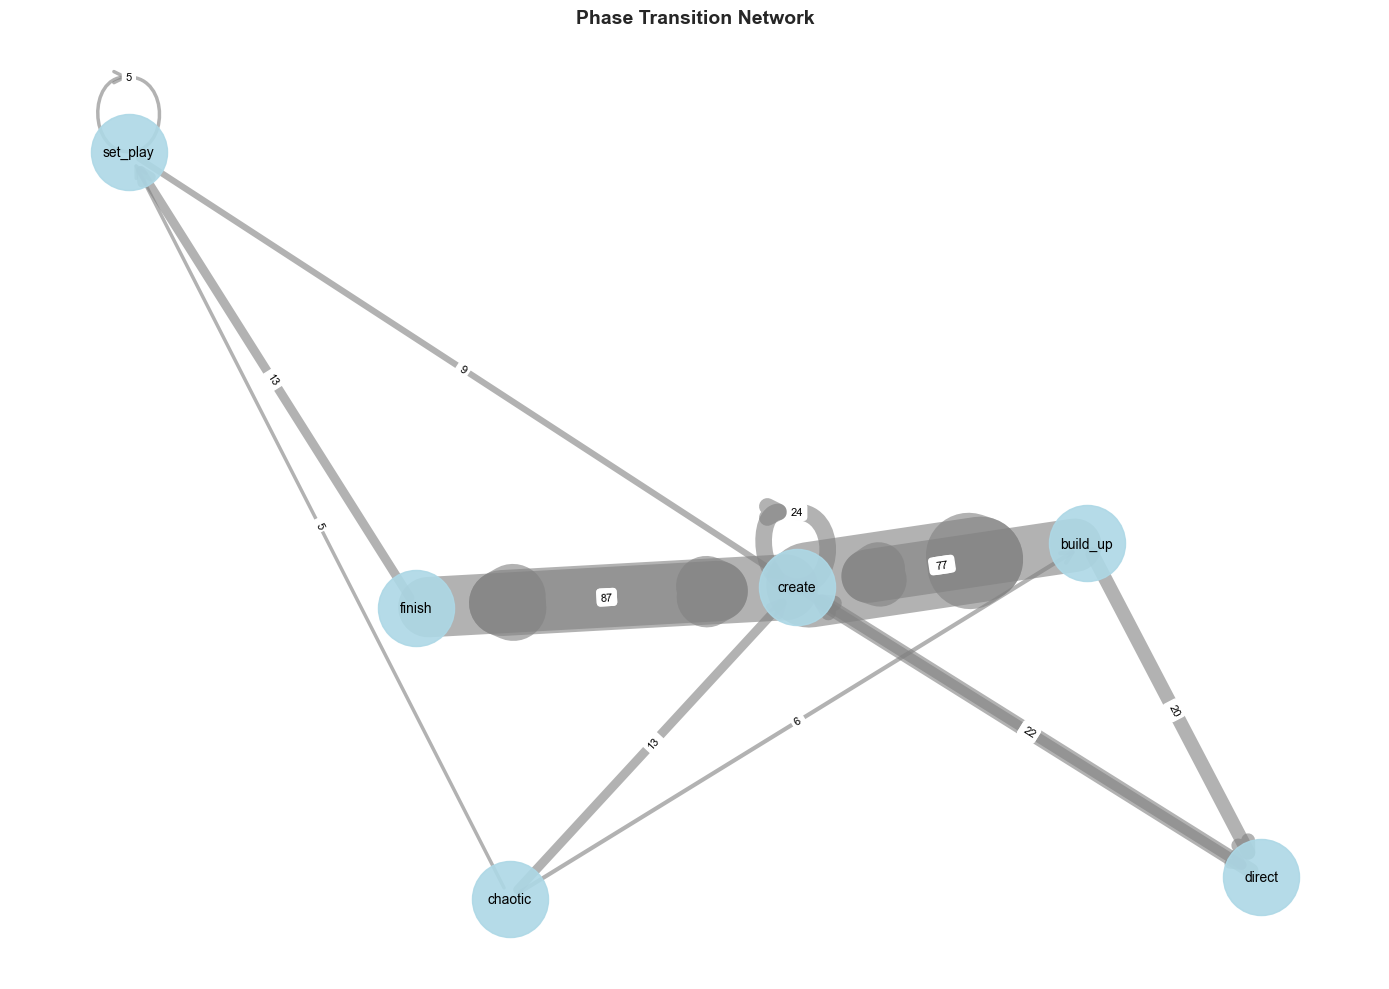

In [29]:
# Visualize transition network
edges, nodes = get_transition_network(phases_df, min_count=5)
fig = plot_transition_network(edges, nodes, figsize=(14, 10))
plt.show()


### 2.2 Transition Success Rates

Analyzing which transitions lead to goals and shots reveals the most effective tactical sequences.


In [30]:
# Calculate transition success rates
success_rates = get_transition_success_rates(phases_df)
print("Top 10 Transitions by Goal Rate:")
success_rates[['transition', 'total_transitions', 'transition_leads_to_goal', 'goal_rate']].head(10)


Top 10 Transitions by Goal Rate:


,transition,total_transitions,transition_leads_to_goal,goal_rate
30,transition -> finish,1,1,100.000000
28,set_play -> set_play,5,1,20.000000
23,finish -> set_play,13,1,7.692308
13,create -> direct,14,1,7.142857
2,build_up -> create,77,2,2.597403
14,create -> finish,95,2,2.105263
10,create -> build_up,123,1,0.813008
0,build_up -> build_up,3,0,0.000000
20,finish -> chaotic,1,0,0.000000
21,finish -> create,87,0,0.000000


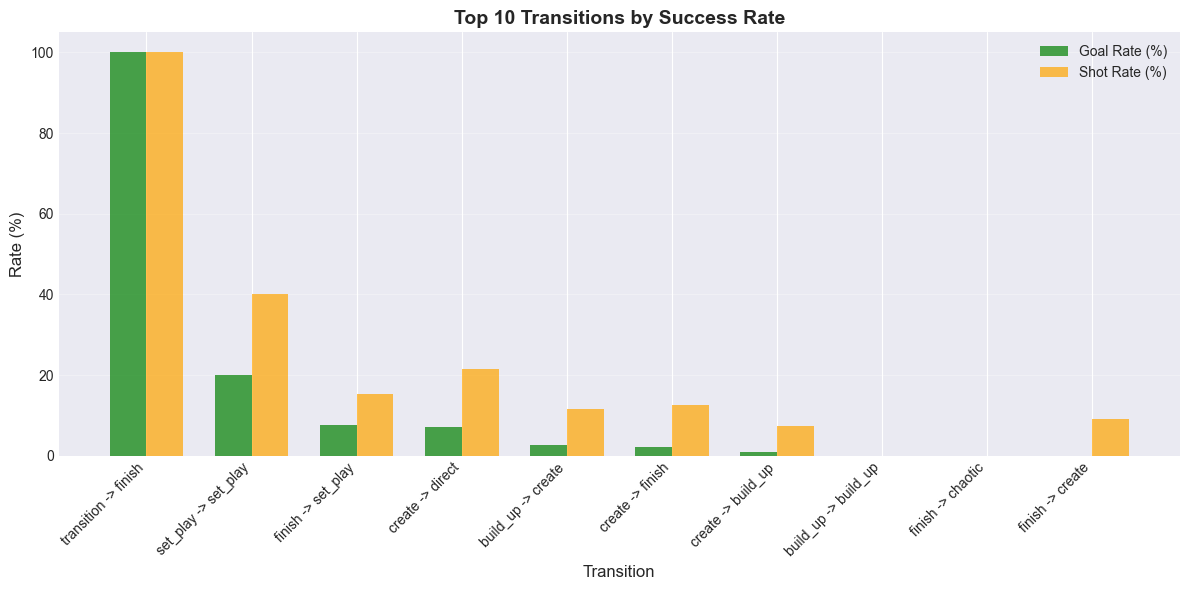

In [31]:
# Visualize success rates
fig = plot_transition_success_rates(success_rates, top_n=10, figsize=(12, 6))
plt.show()


### 2.3 Spatial Analysis of Transitions

Understanding where on the pitch successful transitions occur provides spatial insights for tactical planning.


In [33]:
# Plot transition locations
fig = plot_transition_heatmap(phases_df, figsize=(12, 8))
plt.show()


TypeError: bad operand type for unary -: 'NoneType'

In [ ]:
# Heatmap of goal-scoring transitions
fig = plot_spatial_transition_heatmap(phases_df, outcome='goal', figsize=(12, 8))
plt.show()


TypeError: bad operand type for unary -: 'NoneType'

## 3. Team Comparison

Comparing phase distributions and transition patterns between teams reveals tactical differences.


In [ ]:
# Team phase distribution
team_comparison = get_team_comparison(phases_df)
print("Phase Type Distribution by Team:")
team_comparison.head(20)


Phase Type Distribution by Team:


,team,phase_type,count,percentage
0,Auckland FC,chaotic,147,31.818182
1,Auckland FC,create,135,29.220779
2,Auckland FC,finish,62,13.419913
3,Auckland FC,build_up,44,9.523810
4,Auckland FC,direct,41,8.874459
5,Auckland FC,transition,16,3.463203
6,Auckland FC,set_play,14,3.030303
7,Auckland FC,quick_break,3,0.649351
8,Macarthur FC,create,72,36.180905
9,Macarthur FC,chaotic,40,20.100503


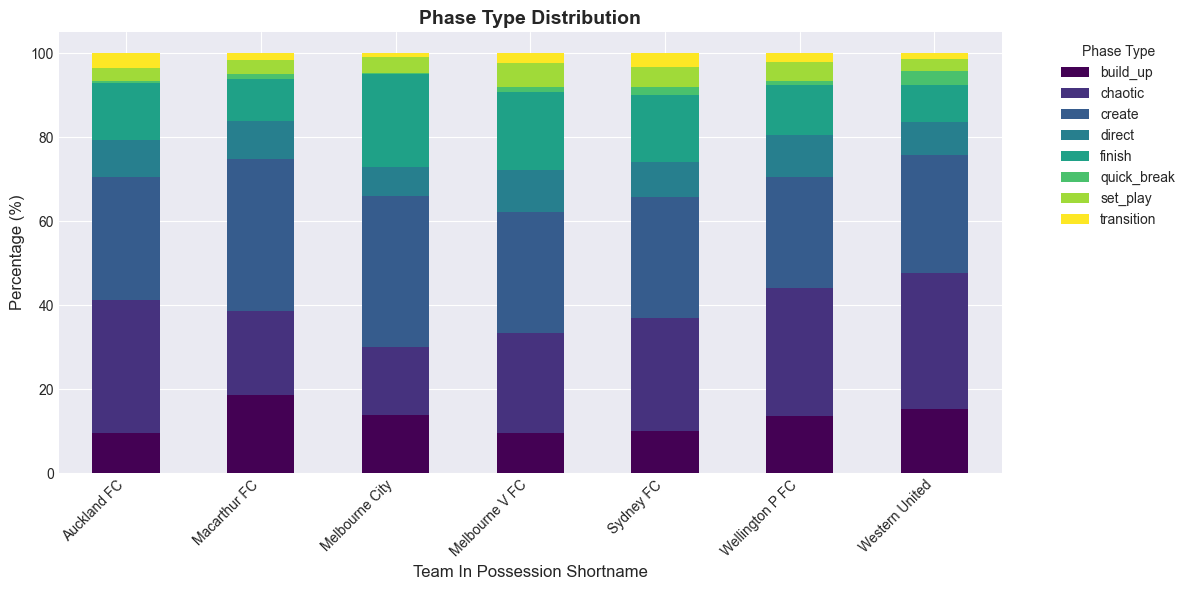

In [ ]:
# Visualize phase distribution
fig = plot_phase_distribution(phases_df, group_by='team_in_possession_shortname', figsize=(12, 6))
plt.show()


## 4. Key Insights

### Summary of Findings:

1. **Most Effective Transitions**: Transitions from 'create' to 'finish' phases show the highest goal rates, indicating successful progression through the pitch.

2. **Spatial Patterns**: Goal-scoring transitions frequently originate in the middle third and progress into the attacking third, with successful finishes occurring in the penalty area.

3. **Team Differences**: Teams vary significantly in their phase distributions, with some favoring direct play while others prefer build-up phases.

4. **Sequence Analysis**: The most successful sequences typically involve 3-4 phase transitions, progressing from defensive organization through creation to finishing.

### Applications:

- **Coaching**: Identify which phase transitions are most effective for a team's playing style
- **Opposition Analysis**: Understand opponent transition patterns to develop defensive strategies
- **Player Development**: Train players to recognize and execute successful transition sequences
- **Tactical Planning**: Design training sessions focused on improving specific transition types
